Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


Generating harmonic oscillator dataset for MBAR FES parity...
Total samples N = 30000

          RUNNING REFERENCE FRAMEWORK (pymbar)
-> Reference MBAR FES finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy MBAR FES finished.

          PARITY VALIDATION
Pearson R: 1.000000
MSE      : 0.00e+00

Plot saved to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_mbar\verify_parity_mbar_fes_plot.png
SUCCESS: DimRedPy FES perfectly matches pymbar reference.


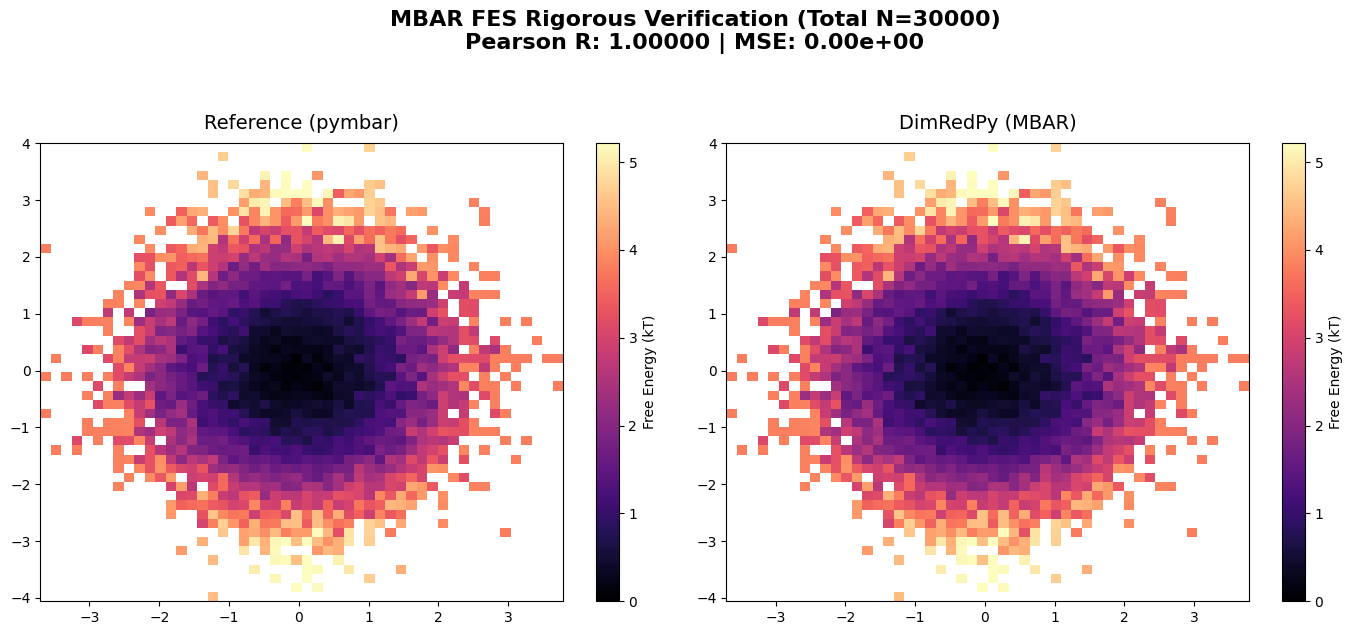

In [1]:
"""
Rigorous Verification of MBAR Parity: Free Energy Surface
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from pymbar import MBAR
from pymbar.testsystems import HarmonicOscillatorsTestCase
from dimredpy.mbar import mbar_free_energy_surface

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating harmonic oscillator dataset for MBAR FES parity...")
n_states = 3
samples_per_state = 10000
testcase = HarmonicOscillatorsTestCase(O_k=[0, 0, 0], K_k=[1, 2, 3])
x_n, u_kn, N_k, s_n = testcase.sample(N_k=[samples_per_state] * n_states)

# Create 2D collective variables (CVs). We'll make CV1 the actual x_n, and CV2 some synthetic noise.
cv2 = np.random.normal(0, 1.0, size=len(x_n))
cv = np.column_stack((x_n, cv2))

temperatures = np.array([300.0, 310.0, 320.0]) # Dummy temperatures
# We need energies in kT. We can just use u_kn[0] as the nominal energies for DimRedPy input
# since we generated u_kn directly. Wait, DimRedPy takes `energies, temperatures`.
# In DimRedPy, mbar_free_energy_surface internally builds u_kn by dividing energies by kT.
# Let's bypass that by passing pre-computed u_kn to mbar_kwargs or by creating energies = u_kn[0] * (kB * T).
# Actually, the simplest is to just use DimRedPy's internal `build_probability_surface` directly 
# since we already have u_kn, or we can just pass energies that evaluate to u_kn.
from dimredpy.mbar import run_mbar
from dimredpy.mbar.mbar import build_probability_surface

print(f"Total samples N = {len(x_n)}")

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (pymbar)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (pymbar)")
print("=======================================================")

mbar_ref = MBAR(u_kn, N_k, solver_protocol="default")
W_nk_ref = mbar_ref.W_nk

# Grid the weights manually for reference
ref_surf = build_probability_surface(
    cv, 
    mbar_weights=W_nk_ref.T, # Weights should be (K, N_total)
    state_index=0,
    n_bins=50, 
    kde=False
)
ref_prob = ref_surf["probability"]
ref_fes = ref_surf["free_energy"]
bin_centers_x = ref_surf["bin_centers_x"]
bin_centers_y = ref_surf["bin_centers_y"]

print("-> Reference MBAR FES finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

res_dimredpy = run_mbar(u_kn, N_k, solver="default")
W_nk_dimred = res_dimredpy["weights"]

dimred_surf = build_probability_surface(
    cv, 
    mbar_weights=W_nk_dimred,
    state_index=0,
    n_bins=50, 
    kde=False
)
dimred_prob = dimred_surf["probability"]
dimred_fes = dimred_surf["free_energy"]

print("-> DimRedPy MBAR FES finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation & Plotting
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

# Mask nans for comparison
mask = ~np.isnan(ref_fes) & ~np.isinf(ref_fes) & ~np.isnan(dimred_fes) & ~np.isinf(dimred_fes)

mse = np.mean((ref_fes[mask] - dimred_fes[mask]) ** 2)
r_val, _ = pearsonr(ref_fes[mask], dimred_fes[mask])

print(f"Pearson R: {r_val:.6f}")
print(f"MSE      : {mse:.2e}")

# Generate exactly the plot structure requested
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"MBAR FES Rigorous Verification (Total N={len(x_n)})\nPearson R: {r_val:.5f} | MSE: {mse:.2e}", 
             fontsize=16, fontweight='bold', y=1.05)

X, Y = np.meshgrid(bin_centers_x, bin_centers_y)

# Reference Plot
im1 = axes[0].pcolormesh(X, Y, ref_fes.T, cmap='magma', shading='auto', vmin=0, vmax=np.nanmax(ref_fes[mask]))
axes[0].set_title("Reference (pymbar)", fontsize=14, pad=10)
fig.colorbar(im1, ax=axes[0], label="Free Energy (kT)")

# DimRedPy Plot
im2 = axes[1].pcolormesh(X, Y, dimred_fes.T, cmap='magma', shading='auto', vmin=0, vmax=np.nanmax(ref_fes[mask]))
axes[1].set_title("DimRedPy (MBAR)", fontsize=14, pad=10)
fig.colorbar(im2, ax=axes[1], label="Free Energy (kT)")

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_mbar_fes_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to {plot_path}")

if mse < 1e-10 and r_val > 0.99999:
    print("SUCCESS: DimRedPy FES perfectly matches pymbar reference.")
else:
    print("FAILURE: Statistical divergence detected in MBAR FES parity.")
